In [1]:
# Імпорт бібліотек для обробки зображень та візуалізації, налаштування розміру графіків
import cv2
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 10]


(<Axes: >, <matplotlib.image.AxesImage at 0x1f6da5b5e50>)

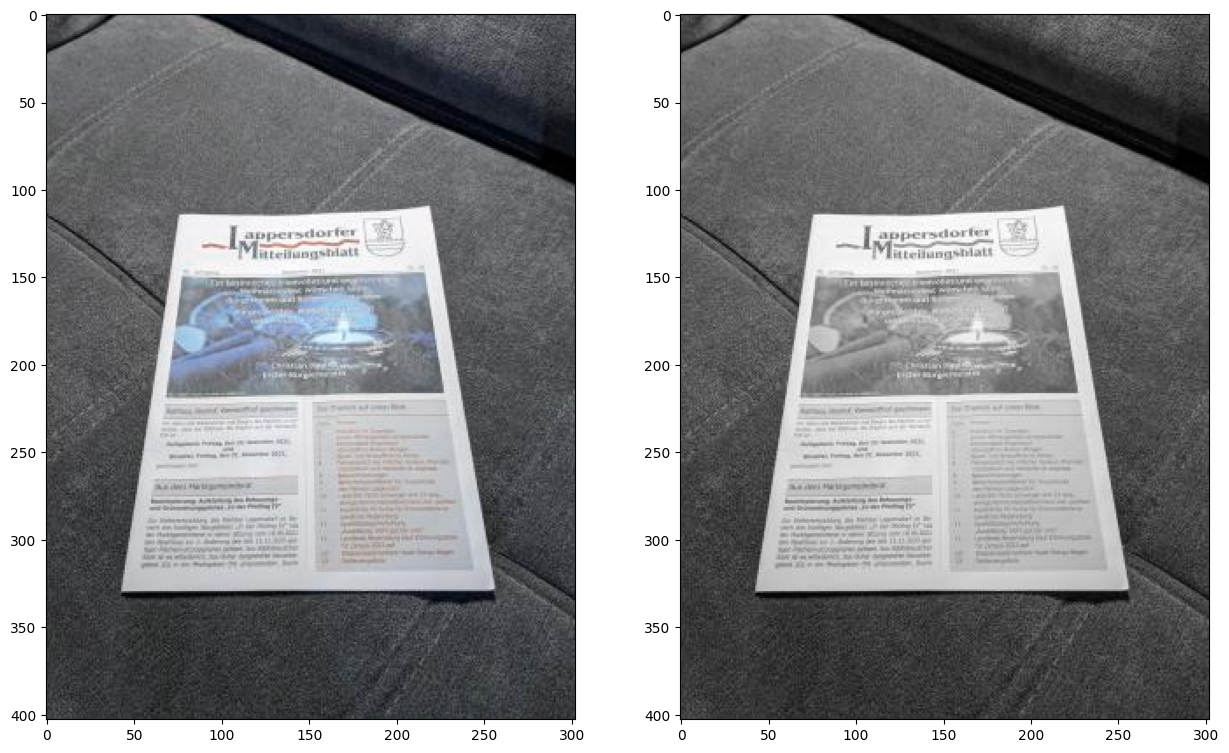

In [2]:
# Зчитування зображення
img = cv2.imread('document (1).jpg')
# Перетворення в градації сірого та нормалізація
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
gray = np.float32(gray)/255
# Отримання розмірів зображення
rows, cols = gray.shape
# Відображення оригіналу та обробленого зображення
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(gray, cmap='gray')

In [3]:
# Обчислення міри "кутовості" (Harris Corner Detector)
cornerness = cv2.cornerHarris(gray.astype(np.float32), blockSize=2, ksize=3, k=0.04)
# Видалення від’ємних значень
cornerness = cornerness.clip(min=0)

# Логарифмічне масштабування для покращення візуалізації
cornerness = np.log(cornerness + 1e-6)

(<Axes: >, <matplotlib.image.AxesImage at 0x1f6da9f1f90>)

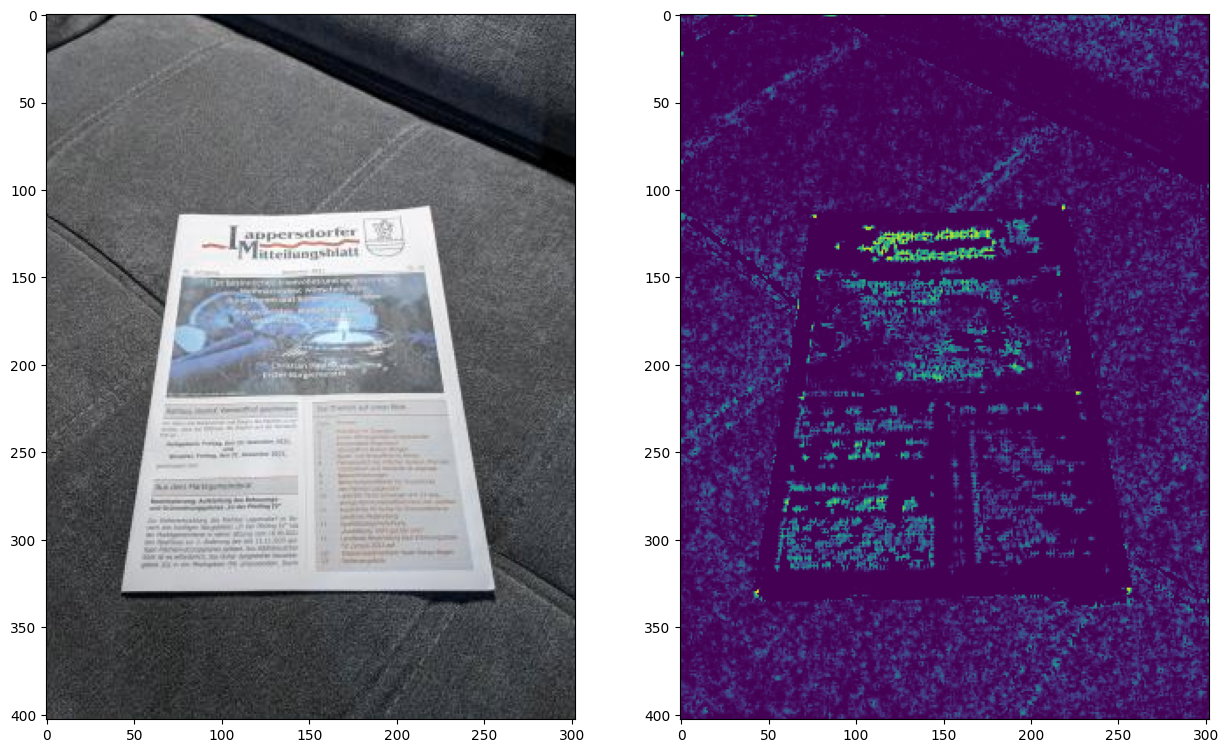

In [4]:
# Відображення оригінального зображення та карти кутів
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(cornerness)

(<Axes: >, <matplotlib.image.AxesImage at 0x1f6dab21590>)

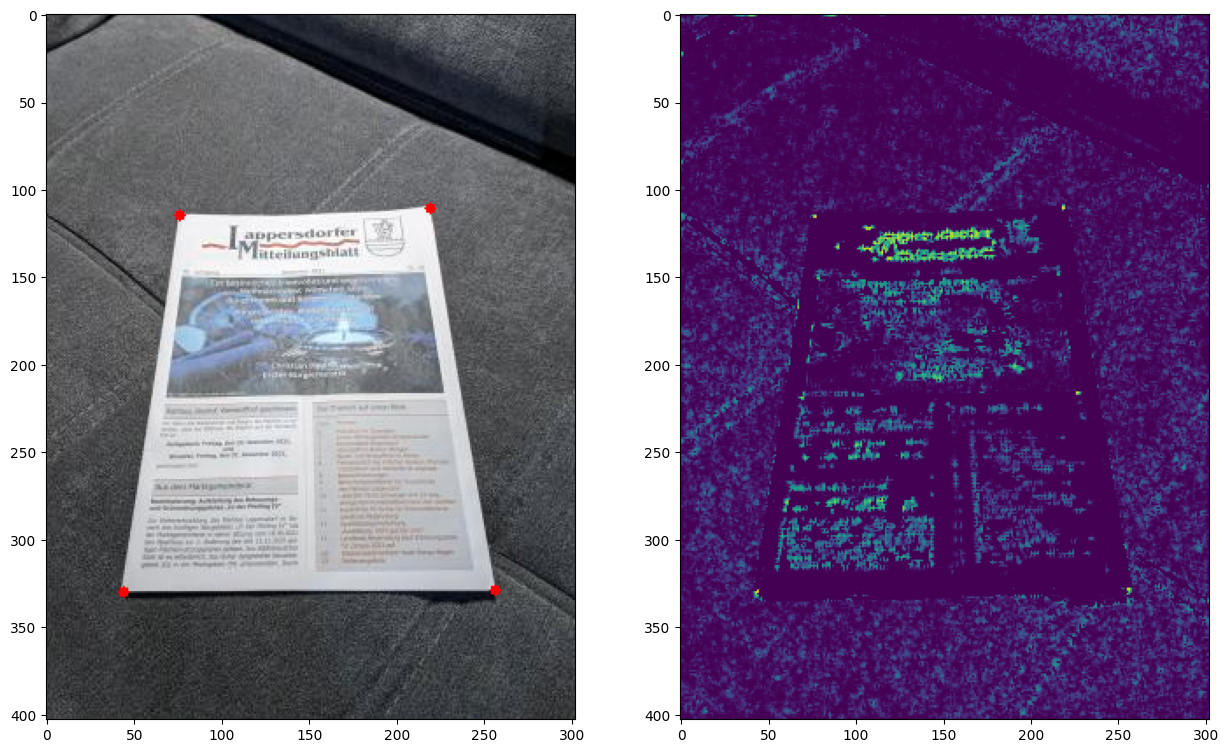

In [5]:
# Ініціалізація порогів і оптимальних точок
th_top_left, th_top_right = -1e6, -1e6
th_bottom_left, th_bottom_right = -1e6, -1e6

opt_top_left, opt_top_right = None, None
opt_bottom_left, opt_bottom_ritgh = None, None

# Розмір області (квадранта) для аналізу
quad_size = 7

# Перебір пікселів (без країв)
for r in range(quad_size, rows-quad_size):
    for c in range(quad_size, cols-quad_size):

        # Відсів слабких кутів
        if cornerness[r, c] < -7:
            continue

        # Виділення локального блоку
        block = 255*gray[r-quad_size:r+quad_size+1, c-quad_size:c+quad_size+1]



        # Розбиття блоку на 4 квадранти
        quad_top_left = block[0:quad_size, 0:quad_size]
        quad_top_right = block[quad_size:quad_size*2, 0:quad_size]
        quad_bottom_left = block[0:quad_size, quad_size:quad_size*2]
        quad_bottom_right = block[quad_size:quad_size*2, quad_size:quad_size*2]


        # Обчислення дескрипторів і пошук найкращих точок
        descriptor = np.mean(quad_bottom_right) - \
                     np.mean(quad_top_left) - np.mean(quad_top_right) - np.mean(quad_bottom_left)
        if descriptor > th_top_left:

            th_top_left = descriptor
            opt_top_left = (c, r)


        descriptor = np.mean(quad_bottom_left) - \
                     np.mean(quad_top_left) - np.mean(quad_top_right) - np.mean(quad_bottom_right)

        if descriptor > th_top_right:

            th_top_right = descriptor

            opt_top_right = (c, r)

        descriptor = np.mean(quad_top_right) - \
                     np.mean(quad_top_left) - np.mean(quad_bottom_left) - np.mean(quad_bottom_right)

        if descriptor > th_bottom_left:

            th_bottom_left = descriptor

            opt_bottom_left = (c, r)

        descriptor = np.mean(quad_top_left) - \
                     np.mean(quad_top_right) - np.mean(quad_bottom_left) - np.mean(quad_bottom_right)

        if descriptor > th_bottom_right:
            th_bottom_right= descriptor
            opt_bottom_right = (c, r)

# Позначення знайдених точок на зображенні
out = cv2.circle(img, opt_top_left, 3, (255,0,0), -1)
out = cv2.circle(img, opt_top_right, 3, (255,0,0), -1)
out = cv2.circle(img, opt_bottom_left, 3, (255,0,0), -1)
out = cv2.circle(img, opt_bottom_right, 3, (255,0,0), -1)


# Відображення результату та карти кутів
plt.subplot(121), plt.imshow(out)
plt.subplot(122), plt.imshow(cornerness)

## Висновок



In [12]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

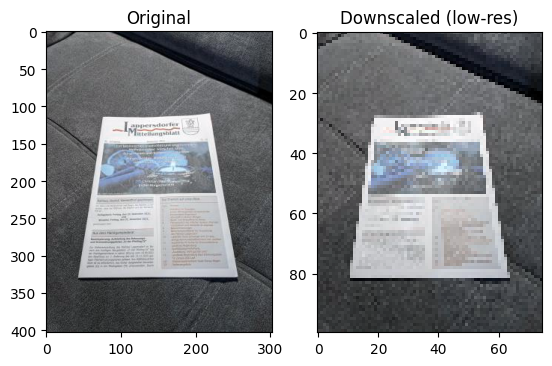

In [19]:
img = cv2.imread('document (1).jpg')

rows, cols = img.shape[:2]

small = cv2.resize(img, (cols//4, rows//4))
small_gray = cv2.cvtColor(small, cv2.COLOR_RGB2GRAY)
small_gray = np.float32(small_gray) / 255

plt.subplot(121), plt.title("Original")
plt.imshow(img)

plt.subplot(122), plt.title("Downscaled (low-res)")
plt.imshow(small)

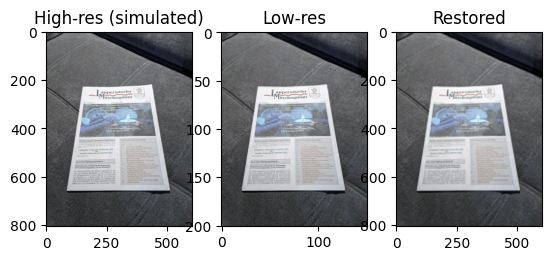

In [20]:
high_res = cv2.resize(img, (cols*2, rows*2), interpolation=cv2.INTER_CUBIC)

# 2. Downscale (імітація стиснення/сенсора)
low_res = cv2.resize(high_res, (cols//2, rows//2), interpolation=cv2.INTER_AREA)

# 3. Upscale назад
restored = cv2.resize(low_res, (cols*2, rows*2), interpolation=cv2.INTER_CUBIC)

# Візуалізація
plt.subplot(131), plt.title("High-res (simulated)")
plt.imshow(high_res)

plt.subplot(132), plt.title("Low-res")
plt.imshow(low_res)

plt.subplot(133), plt.title("Restored")
plt.imshow(restored)

plt.show()

Так, роздільна здатність має значення. Фото з 12Mpx містить більше деталей, тому алгоритм знаходить більше і точніші ознаки. У 1Mpx зображенні частина інформації втрачається, через що результат гірший і менш стабільний.

Якщо збільшити роздільну здатність камери, зображення міститиме значно більше деталей, але також зросте навантаження на пам’ять і час обробки. У поточному алгоритмі потрібно використовувати якіснішу інтерполяцію при зменшенні (наприклад, INTER_AREA) та замінити фіксоване масштабування cols//4 на адаптивне залежно від масштабу сцени або DPI. Також доцільно додати anti-aliasing і попередню фільтрацію шуму, щоб зберегти якість при роботі з високороздільними зображеннями.